In [1]:
!pip install /kaggle/input/rdkit-2025-3-3-cp311/rdkit-2025.3.3-cp311-cp311-manylinux_2_28_x86_64.whl
!pip install mordred --no-index --find-links=file:///kaggle/input/mordred-1-2-0-py3-none-any/
!pip install torch_geometric --no-index --find-links=file:/kaggle/input/torch-geometric-2-6-1-whl/torch_geometric-2.6.1-py3-none-any.whl

Processing /kaggle/input/rdkit-2025-3-3-cp311/rdkit-2025.3.3-cp311-cp311-manylinux_2_28_x86_64.whl
Looking in links: file:///kaggle/input/mordred-1-2-0-py3-none-any/
Processing /kaggle/input/mordred-1-2-0-py3-none-any/mordred-1.2.0-py3-none-any.whl
Processing /kaggle/input/mordred-1-2-0-py3-none-any/networkx-2.8.8-py3-none-any.whl (from mordred)
  Attempting uninstall: networkx
    Found existing installation: networkx 3.5
    Uninstalling networkx-3.5:
      Successfully uninstalled networkx-3.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-image 0.25.2 requires networkx>=3.0, but you have networkx 2.8.8 which is incompatible.
nx-cugraph-cu12 25.2.0 requires networkx>=3.2, but you have networkx 2.8.8 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have

In [2]:
import warnings
warnings.simplefilter(action='ignore')

import os
import re
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GCNConv, GATConv, GraphConv, global_mean_pool, global_max_pool, global_add_pool, global_sort_pool
from torch_geometric.data import Data, Batch
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from collections import defaultdict
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, Descriptors, Crippen, Lipinski
import networkx as nx

# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load data
train = pd.read_csv('/kaggle/input/neurips-open-polymer-prediction-2025/train.csv')
test = pd.read_csv('/kaggle/input/neurips-open-polymer-prediction-2025/test.csv')

Using device: cuda


In [3]:
class ImprovedSMILESToGraph:
    """Enhanced SMILES to molecular graph converter using RDKit"""
    
    def __init__(self):
        # Extended atom vocabulary
        self.atom_types = ['C', 'N', 'O', 'S', 'P', 'F', 'Cl', 'Br', 'I', 'H', 'B', 'Si', 
                          'Se', 'Te', 'As', 'Na', 'K', 'Li', 'Mg', 'Ca', 'Al', 'Zn', 'Fe']
        self.atom_to_idx = {atom: idx for idx, atom in enumerate(self.atom_types)}
        self.atom_to_idx['UNK'] = len(self.atom_types)
        
        # Hybridization types
        self.hybridization_types = [
            Chem.rdchem.HybridizationType.SP,
            Chem.rdchem.HybridizationType.SP2, 
            Chem.rdchem.HybridizationType.SP3,
            Chem.rdchem.HybridizationType.SP3D,
            Chem.rdchem.HybridizationType.SP3D2,
            Chem.rdchem.HybridizationType.UNSPECIFIED
        ]
        
        # Bond types
        self.bond_types = [
            Chem.rdchem.BondType.SINGLE,
            Chem.rdchem.BondType.DOUBLE,
            Chem.rdchem.BondType.TRIPLE,
            Chem.rdchem.BondType.AROMATIC,
        ]
        
        # Atomic properties
        self.electronegativity = {
            'C': 2.55, 'N': 3.04, 'O': 3.44, 'S': 2.58, 'P': 2.19, 'F': 3.98,
            'Cl': 3.16, 'Br': 2.96, 'I': 2.66, 'H': 2.20, 'B': 2.04, 'Si': 1.90,
            'Se': 2.55, 'Te': 2.1, 'As': 2.18, 'Na': 0.93, 'K': 0.82, 'Li': 0.98,
            'Mg': 1.31, 'Ca': 1.00, 'Al': 1.61, 'Zn': 1.65, 'Fe': 1.83
        }
        
        self.covalent_radius = {
            'C': 0.76, 'N': 0.71, 'O': 0.66, 'S': 1.05, 'P': 1.07, 'F': 0.57,
            'Cl': 0.99, 'Br': 1.14, 'I': 1.33, 'H': 0.31, 'B': 0.84, 'Si': 1.11,
            'Se': 1.20, 'Te': 1.38, 'As': 1.19, 'Na': 1.66, 'K': 2.03, 'Li': 1.28,
            'Mg': 1.41, 'Ca': 1.76, 'Al': 1.21, 'Zn': 1.22, 'Fe': 1.52
        }
    
    def get_atom_features(self, atom):
        """Extract comprehensive atom features using RDKit"""
        try:
            features = []
            
            # Basic atom properties
            atomic_num = atom.GetAtomicNum()
            atom_symbol = atom.GetSymbol()
            
            # One-hot encoding for atom type (limited to common atoms)
            atom_onehot = [0] * (len(self.atom_types) + 1)
            if atom_symbol in self.atom_to_idx:
                atom_onehot[self.atom_to_idx[atom_symbol]] = 1
            else:
                atom_onehot[self.atom_to_idx['UNK']] = 1
            features.extend(atom_onehot)
            
            # Degree (number of bonded atoms)
            degree = atom.GetDegree()
            degree_onehot = [0] * 7  # 0-6 bonds
            if degree < 7:
                degree_onehot[degree] = 1
            features.extend(degree_onehot)
            
            # Formal charge
            formal_charge = atom.GetFormalCharge()
            features.append(formal_charge)
            
            # Hybridization
            try:
                hybridization = atom.GetHybridization()
                hyb_onehot = [0] * len(self.hybridization_types)
                if hybridization in self.hybridization_types:
                    hyb_onehot[self.hybridization_types.index(hybridization)] = 1
                features.extend(hyb_onehot)
            except:
                features.extend([0] * len(self.hybridization_types))
            
            # Aromaticity
            features.append(int(atom.GetIsAromatic()))
            
            # Ring membership
            features.append(int(atom.IsInRing()))
            
            # Number of implicit hydrogens
            features.append(atom.GetTotalNumHs())
            
            # Valence
            try:
                features.append(atom.GetTotalValence())
            except:
                features.append(0)
            
            # Electronegativity
            electronegativity = self.electronegativity.get(atom_symbol, 2.5)
            features.append(electronegativity)
            
            # Covalent radius
            cov_radius = self.covalent_radius.get(atom_symbol, 1.0)
            features.append(cov_radius)
            
            # Mass (normalized)
            mass = atom.GetMass() / 100.0
            features.append(mass)
            
            # Chirality
            try:
                chiral_tag = atom.GetChiralTag()
                features.append(int(chiral_tag != Chem.rdchem.ChiralType.CHI_UNSPECIFIED))
            except:
                features.append(0)
            
            return features
            
        except Exception as e:
            print(f"Error in get_atom_features: {e}")
            # Return default features
            return [1] + [0] * 43  # Approximate feature length
    
    def get_bond_features(self, bond):
        """Extract bond features"""
        try:
            features = []
            
            # Bond type one-hot
            bond_type = bond.GetBondType()
            bond_onehot = [0] * len(self.bond_types)
            if bond_type in self.bond_types:
                bond_onehot[self.bond_types.index(bond_type)] = 1
            features.extend(bond_onehot)
            
            # Conjugation
            features.append(int(bond.GetIsConjugated()))
            
            # Ring membership
            features.append(int(bond.IsInRing()))
            
            # Stereo
            stereo = bond.GetStereo()
            features.append(int(stereo != Chem.rdchem.BondStereo.STEREONONE))
            
            return features
            
        except Exception as e:
            print(f"Error in get_bond_features: {e}")
            return [1, 0, 0, 0, 0, 0, 0]  # Default bond features
    
    def smiles_to_graph(self, smiles):
        """Convert SMILES to molecular graph using RDKit"""
        try:
            # Parse SMILES
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                # Try to clean the SMILES
                mol = Chem.MolFromSmiles(smiles, sanitize=False)
                if mol is None:
                    return self.create_dummy_graph()
                try:
                    Chem.SanitizeMol(mol)
                except:
                    return self.create_dummy_graph()
            
            # Add hydrogens
            mol = Chem.AddHs(mol)
            
            # Get atom features
            atom_features = []
            for atom in mol.GetAtoms():
                atom_feats = self.get_atom_features(atom)
                atom_features.append(atom_feats)
            
            if len(atom_features) == 0:
                return self.create_dummy_graph()
            
            # Pad features to consistent length
            max_feat_len = max(len(feat) for feat in atom_features)
            for i in range(len(atom_features)):
                while len(atom_features[i]) < max_feat_len:
                    atom_features[i].append(0.0)
            
            node_features = torch.tensor(atom_features, dtype=torch.float)
            
            # Get edges and edge features
            edges = []
            edge_features = []
            
            for bond in mol.GetBonds():
                i = bond.GetBeginAtomIdx()
                j = bond.GetEndAtomIdx()
                
                edge_feat = self.get_bond_features(bond)
                
                # Add both directions for undirected graph
                edges.extend([[i, j], [j, i]])
                edge_features.extend([edge_feat, edge_feat])
            
            if len(edges) == 0:
                # Single atom molecule - add self loop
                edges = [[0, 0]]
                edge_features = [[1, 0, 0, 0, 0, 0, 0]]
            
            edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
            edge_attr = torch.tensor(edge_features, dtype=torch.float)
            
            # Add global molecular features
            global_feats = self.get_global_features(mol, smiles)
            
            return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, 
                       global_feats=global_feats)
            
        except Exception as e:
            print(f"Error processing SMILES {smiles}: {e}")
            return self.create_dummy_graph()
    
    def get_global_features(self, mol, smiles):
        """Extract global molecular features"""
        try:
            features = []
            
            # Basic descriptors
            features.append(mol.GetNumAtoms())
            features.append(mol.GetNumBonds())
            features.append(mol.GetNumHeavyAtoms())
            
            # Rings
            features.append(rdMolDescriptors.CalcNumRings(mol))
            features.append(rdMolDescriptors.CalcNumAromaticRings(mol))
            features.append(rdMolDescriptors.CalcNumSaturatedRings(mol))
            
            # Molecular weight
            features.append(Descriptors.MolWt(mol) / 1000.0)  # Normalized
            
            # LogP
            try:
                features.append(Crippen.MolLogP(mol))
            except:
                features.append(0.0)
            
            # TPSA
            try:
                features.append(rdMolDescriptors.CalcTPSA(mol) / 100.0)  # Normalized
            except:
                features.append(0.0)
            
            # Lipinski descriptors
            try:
                features.append(Lipinski.NumHDonors(mol))
                features.append(Lipinski.NumHAcceptors(mol))
                features.append(Lipinski.NumRotatableBonds(mol))
            except:
                features.extend([0.0, 0.0, 0.0])
            
            # Fraction of SP3 carbons
            try:
                features.append(rdMolDescriptors.CalcFractionCsp3(mol))
            except:
                features.append(0.0)
            
            return torch.tensor(features, dtype=torch.float)
            
        except Exception as e:
            print(f"Error in global features: {e}")
            return torch.zeros(13, dtype=torch.float)
    
    def create_dummy_graph(self):
        """Create a dummy graph for failed SMILES"""
        node_features = torch.ones(1, 44)  # Approximate feature length
        edge_index = torch.tensor([[0], [0]], dtype=torch.long)
        edge_attr = torch.ones(1, 7)
        global_feats = torch.zeros(13)
        return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, 
                   global_feats=global_feats)


class EnhancedMolecularDataset(Dataset):
    """Enhanced dataset with caching and error handling"""
    
    def __init__(self, smiles_list, targets=None, graph_converter=None, cache_graphs=True):
        self.smiles_list = smiles_list
        self.targets = targets
        self.graph_converter = graph_converter or ImprovedSMILESToGraph()
        self.cache_graphs = cache_graphs
        
        if cache_graphs:
            print("Pre-computing molecular graphs...")
            self.graphs = []
            failed_count = 0
            
            for i, smiles in enumerate(smiles_list):
                if i % 1000 == 0:
                    print(f"Processed {i}/{len(smiles_list)} molecules")
                
                graph = self.graph_converter.smiles_to_graph(smiles)
                if graph.x.shape[0] == 0:  # Empty graph
                    failed_count += 1
                    graph = self.graph_converter.create_dummy_graph()
                
                self.graphs.append(graph)
            
            print(f"Failed to parse {failed_count} SMILES strings")
        else:
            self.graphs = None
    
    def __len__(self):
        return len(self.smiles_list)
    
    def __getitem__(self, idx):
        if self.cache_graphs:
            graph = self.graphs[idx]
        else:
            graph = self.graph_converter.smiles_to_graph(self.smiles_list[idx])
        
        if self.targets is not None:
            target = torch.tensor(self.targets[idx], dtype=torch.float)
            return graph, target
        
        return graph

In [4]:
class MultiScaleGNN(nn.Module):
    """Advanced multi-scale GNN with attention and skip connections"""
    
    def __init__(self, node_input_dim, edge_input_dim, global_input_dim, 
                 hidden_dim=256, output_dim=1, num_layers=6, dropout=0.2):
        super(MultiScaleGNN, self).__init__()
        
        self.num_layers = num_layers
        self.dropout = dropout
        self.hidden_dim = hidden_dim
        
        # Input projections
        self.node_proj = nn.Linear(node_input_dim, hidden_dim)
        self.edge_proj = nn.Linear(edge_input_dim, hidden_dim // 4) if edge_input_dim > 0 else None
        self.global_proj = nn.Linear(global_input_dim, hidden_dim // 2)
        
        # Graph convolution layers with skip connections
        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        self.skip_connections = nn.ModuleList()
        
        for i in range(num_layers):
            if i == 0:
                self.convs.append(GCNConv(hidden_dim, hidden_dim))
            else:
                self.convs.append(GCNConv(hidden_dim, hidden_dim))
            
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
            
            # Skip connection layers
            if i > 0:
                self.skip_connections.append(nn.Linear(hidden_dim, hidden_dim))
        
        # Multi-head attention layers
        self.attention_layers = nn.ModuleList()
        for _ in range(2):
            self.attention_layers.append(
                GATConv(hidden_dim, hidden_dim // 8, heads=8, dropout=dropout, 
                       concat=True, edge_dim=hidden_dim // 4 if self.edge_proj else None)
            )
        
        # Global feature integration
        self.global_integration = nn.Sequential(
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Multi-scale pooling
        self.pool_layers = nn.ModuleList([
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Linear(hidden_dim, hidden_dim // 2)
        ])
        
        # Final prediction network
        final_input_dim = (hidden_dim // 2) * 3 + hidden_dim  # 3 pooling + global
        
        self.prediction_network = nn.Sequential(
            nn.Linear(final_input_dim, hidden_dim * 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout // 2),
            
            nn.Linear(hidden_dim // 4, output_dim)
        )
    
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = getattr(data, 'edge_attr', None)
        global_feats = getattr(data, 'global_feats', None)
        
        # Project inputs
        x = self.node_proj(x)
        x = F.relu(x)
        
        if edge_attr is not None and self.edge_proj is not None:
            edge_attr = self.edge_proj(edge_attr)
        
        # Store initial representation for skip connections
        x_skip = x.clone()
        
        # Apply graph convolutions with skip connections
        for i in range(self.num_layers):
            x_residual = x
            
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            
            # Skip connections (every other layer)
            if i > 0 and i % 2 == 0:
                if i // 2 - 1 < len(self.skip_connections):
                    x_skip_proj = self.skip_connections[i // 2 - 1](x_skip)
                    x = x + x_skip_proj
            
            # Residual connection
            if i > 0:
                x = x + x_residual
        
        # Apply attention layers
        for attention_layer in self.attention_layers:
            x_att = attention_layer(x, edge_index, edge_attr=edge_attr)
            x = x + F.dropout(x_att, p=self.dropout, training=self.training)
        
        # Multi-scale pooling
        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x_add = global_add_pool(x, batch)
        
        # Apply pooling projections
        x_mean = self.pool_layers[0](x_mean)
        x_max = self.pool_layers[1](x_max)
        x_add = self.pool_layers[2](x_add)
        
        # Global features integration
        if global_feats is not None:
            # Handle batch dimension for global features
            if len(global_feats.shape) == 1:
                global_feats = global_feats.unsqueeze(0).repeat(x_mean.shape[0], 1)
            
            global_integrated = self.global_integration(self.global_proj(global_feats))
        else:
            global_integrated = torch.zeros(x_mean.shape[0], self.hidden_dim).to(x.device)
        
        # Concatenate all representations
        x_final = torch.cat([x_mean, x_max, x_add, global_integrated], dim=1)
        
        # Final prediction
        output = self.prediction_network(x_final)
        
        return output

In [5]:
def train_enhanced_model(train_loader, val_loader, node_dim, edge_dim, global_dim, 
                        target_name, epochs=300, patience=50):
    """Train enhanced GNN model with advanced techniques"""
    
    model = MultiScaleGNN(
        node_input_dim=node_dim,
        edge_input_dim=edge_dim, 
        global_input_dim=global_dim,
        hidden_dim=256,
        output_dim=1,
        num_layers=6,
        dropout=0.3
    ).to(device)
    
    # Advanced optimizer and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=0.001, 
        weight_decay=1e-4,
        betas=(0.9, 0.999),
        eps=1e-8
    )
    
    # Cosine annealing with warm restarts
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=50, T_mult=2, eta_min=1e-6
    )
    
    # Loss function with label smoothing
    criterion = nn.L1Loss()  # More robust than MSE for outliers
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    learning_rates = []
    
    print(f"Training enhanced model for {target_name}...")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_count = 0
        
        for batch_data, batch_target in train_loader:
            batch_data = batch_data.to(device)
            batch_target = batch_target.to(device)
            
            optimizer.zero_grad()
            
            output = model(batch_data)
            loss = criterion(output.squeeze(), batch_target)
            
            # L2 regularization on graph representations
            l2_reg = 0
            for name, param in model.named_parameters():
                if 'weight' in name and 'conv' in name:
                    l2_reg += torch.norm(param, p=2)
            
            total_loss = loss + 1e-5 * l2_reg
            
            total_loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            train_count += 1
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_count = 0
        
        with torch.no_grad():
            for batch_data, batch_target in val_loader:
                batch_data = batch_data.to(device)
                batch_target = batch_target.to(device)
                
                output = model(batch_data)
                loss = criterion(output.squeeze(), batch_target)
                
                val_loss += loss.item()
                val_count += 1
        
        # Calculate average losses
        avg_train_loss = train_loss / train_count if train_count > 0 else 0
        avg_val_loss = val_loss / val_count if val_count > 0 else 0
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        learning_rates.append(optimizer.param_groups[0]['lr'])
        
        scheduler.step()
        
        # Early stopping and model saving
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'epoch': epoch,
                'loss': best_val_loss,
            }, f'best_enhanced_gnn_{target_name}.pth')
        else:
            patience_counter += 1
        
        if epoch % 25 == 0 or patience_counter == 0:
            print(f'Epoch {epoch:03d}: Train Loss: {avg_train_loss:.4f}, '
                  f'Val Loss: {avg_val_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.2e}')
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break
    
    # Load best model
    checkpoint = torch.load(f'best_enhanced_gnn_{target_name}.pth')
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model, train_losses, val_losses, learning_rates

Initializing enhanced molecular graph converter...
Creating enhanced molecular datasets...
Pre-computing molecular graphs...
Processed 0/3 molecules
Failed to parse 0 SMILES strings
Node features dimension: 46
Edge features dimension: 7
Global features dimension: 13

Training enhanced model for Tg
Training samples: 511
Pre-computing molecular graphs...
Processed 0/511 molecules
Failed to parse 0 SMILES strings
Training samples: 408
Validation samples: 103
Training enhanced model for Tg...
Epoch 000: Train Loss: 111.4870, Val Loss: 92.3910, LR: 9.99e-04
Epoch 001: Train Loss: 109.0190, Val Loss: 89.8411, LR: 9.96e-04
Epoch 002: Train Loss: 99.2280, Val Loss: 77.1625, LR: 9.91e-04
Epoch 004: Train Loss: 64.9681, Val Loss: 62.8924, LR: 9.76e-04
Epoch 007: Train Loss: 56.6651, Val Loss: 56.2836, LR: 9.38e-04
Epoch 011: Train Loss: 54.3810, Val Loss: 55.9620, LR: 8.65e-04
Epoch 025: Train Loss: 48.6083, Val Loss: 80.3577, LR: 4.69e-04
Epoch 030: Train Loss: 48.0099, Val Loss: 53.6125, LR: 3

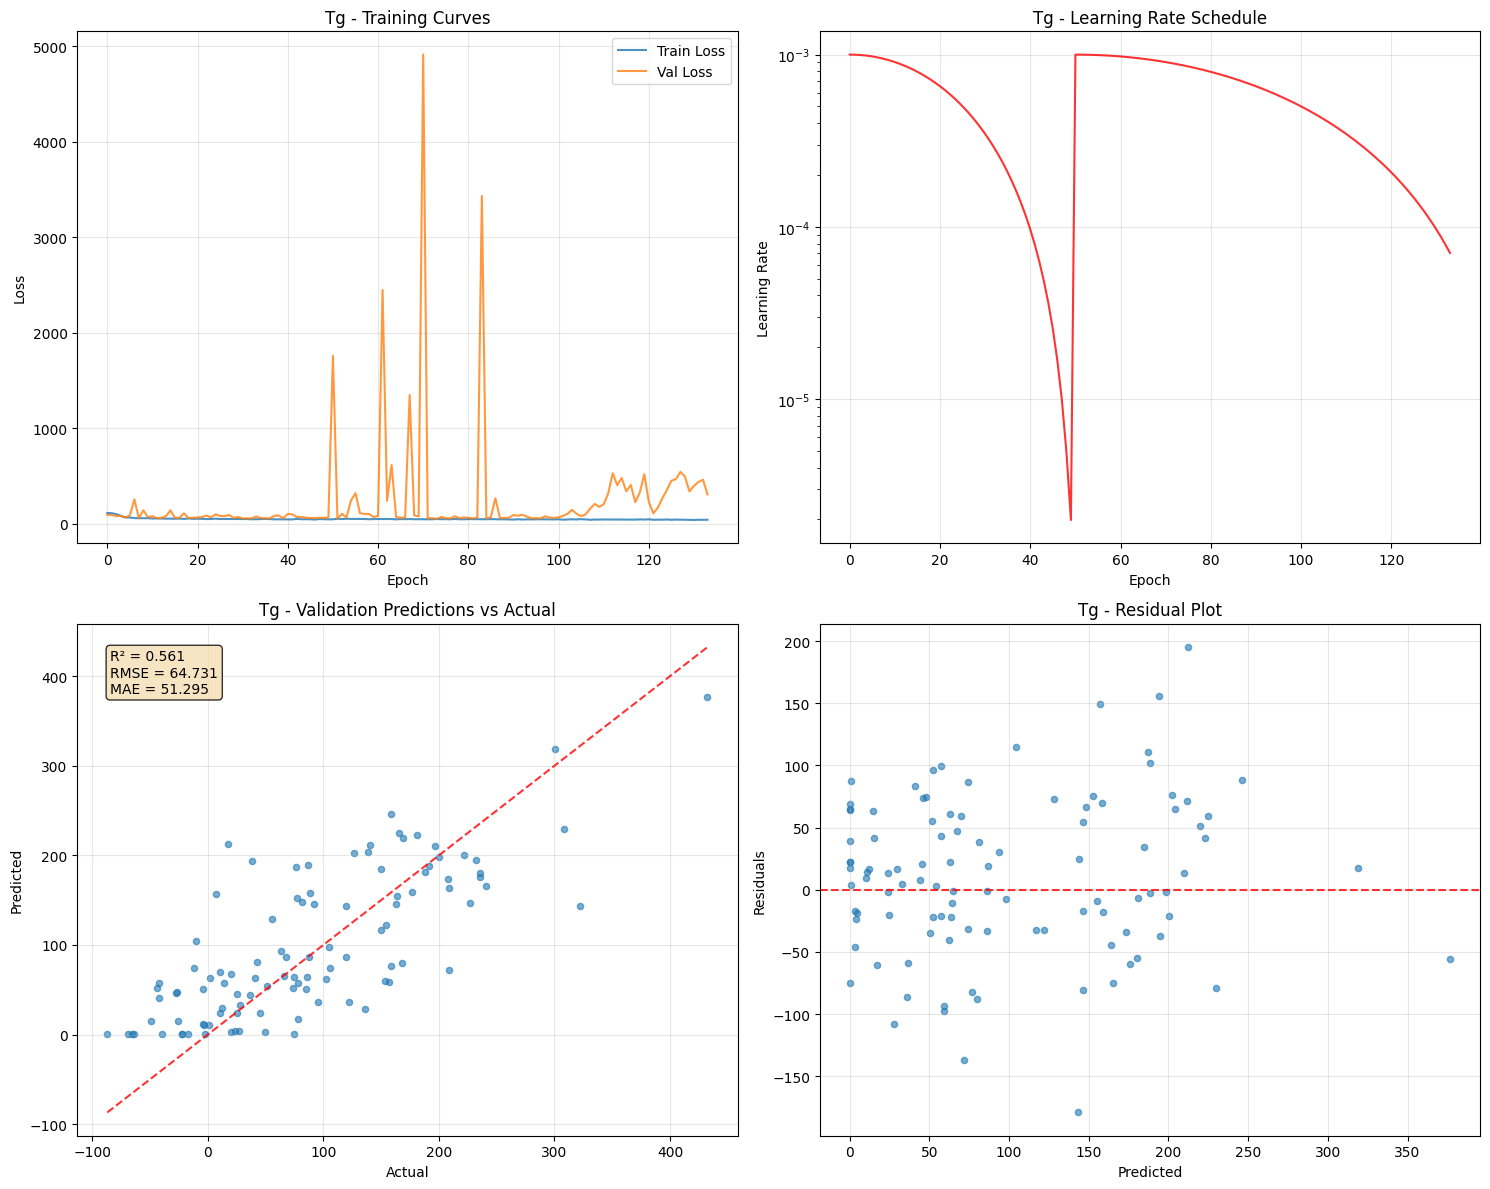


Training enhanced model for FFV
Training samples: 7030
Pre-computing molecular graphs...
Processed 0/7030 molecules
Processed 1000/7030 molecules
Processed 2000/7030 molecules
Processed 3000/7030 molecules
Processed 4000/7030 molecules
Processed 5000/7030 molecules
Processed 6000/7030 molecules
Processed 7000/7030 molecules
Failed to parse 0 SMILES strings
Training samples: 5624
Validation samples: 1406
Training enhanced model for FFV...
Epoch 000: Train Loss: 0.0789, Val Loss: 0.0773, LR: 9.99e-04
Epoch 001: Train Loss: 0.0444, Val Loss: 0.0638, LR: 9.96e-04
Epoch 003: Train Loss: 0.0264, Val Loss: 0.0285, LR: 9.84e-04
Epoch 007: Train Loss: 0.0148, Val Loss: 0.0184, LR: 9.38e-04
Epoch 013: Train Loss: 0.0129, Val Loss: 0.0179, LR: 8.19e-04
Epoch 025: Train Loss: 0.0109, Val Loss: 0.6369, LR: 4.69e-04
Epoch 050: Train Loss: 0.0110, Val Loss: 0.4246, LR: 1.00e-03
Early stopping at epoch 73
Making predictions on test set...
Completed training for FFV
Test predictions range: [0.355, 0.3

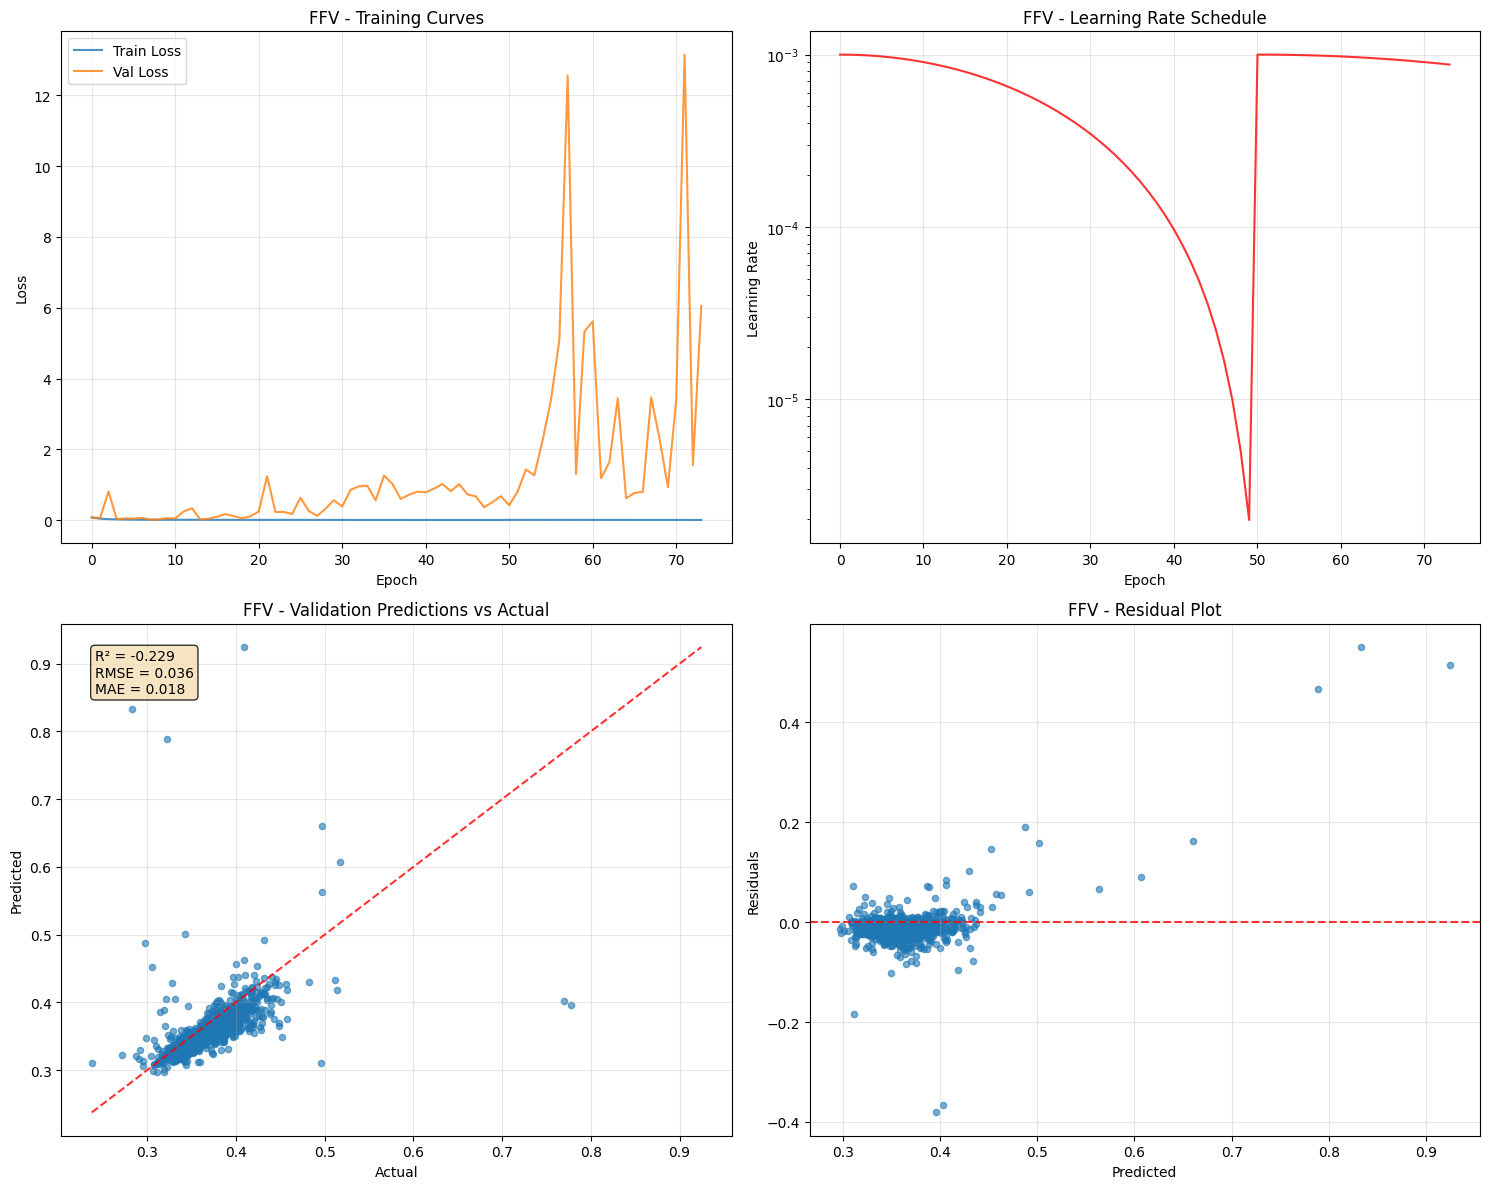


Training enhanced model for Tc
Training samples: 737
Pre-computing molecular graphs...
Processed 0/737 molecules
Failed to parse 0 SMILES strings
Training samples: 589
Validation samples: 148
Training enhanced model for Tc...
Epoch 000: Train Loss: 0.1207, Val Loss: 0.0530, LR: 9.99e-04
Epoch 001: Train Loss: 0.0744, Val Loss: 0.0472, LR: 9.96e-04
Epoch 008: Train Loss: 0.0450, Val Loss: 0.0372, LR: 9.22e-04
Epoch 020: Train Loss: 0.0376, Val Loss: 0.0317, LR: 6.25e-04
Epoch 025: Train Loss: 0.0361, Val Loss: 0.0392, LR: 4.69e-04
Epoch 050: Train Loss: 0.0356, Val Loss: 0.0562, LR: 1.00e-03
Epoch 066: Train Loss: 0.0345, Val Loss: 0.0306, LR: 9.30e-04
Epoch 075: Train Loss: 0.0308, Val Loss: 0.2273, LR: 8.42e-04
Epoch 100: Train Loss: 0.0275, Val Loss: 0.6589, LR: 4.85e-04
Epoch 125: Train Loss: 0.0255, Val Loss: 0.6542, LR: 1.36e-04
Early stopping at epoch 126
Making predictions on test set...
Completed training for Tc
Test predictions range: [0.212, 0.269]


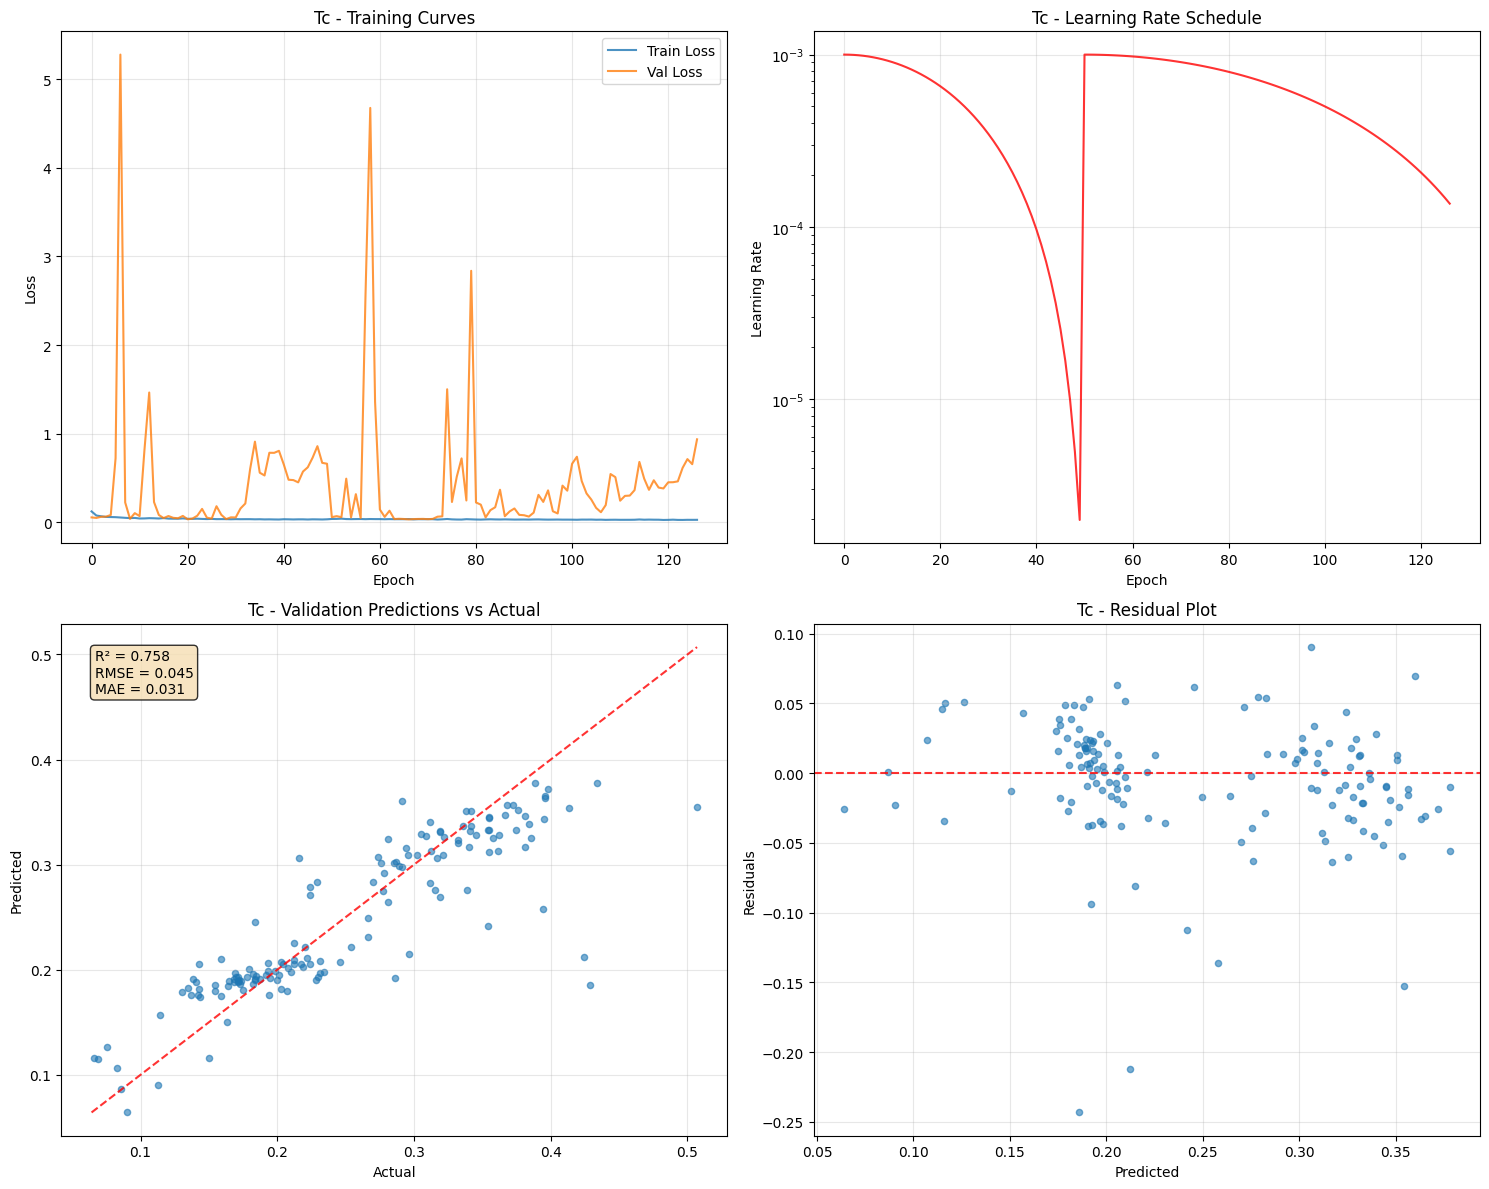


Training enhanced model for Density
Training samples: 613
Pre-computing molecular graphs...
Processed 0/613 molecules
Failed to parse 0 SMILES strings
Training samples: 490
Validation samples: 123
Training enhanced model for Density...
Epoch 000: Train Loss: 0.5254, Val Loss: 0.4913, LR: 9.99e-04
Epoch 001: Train Loss: 0.1952, Val Loss: 0.4479, LR: 9.96e-04
Epoch 002: Train Loss: 0.1946, Val Loss: 0.3097, LR: 9.91e-04
Epoch 003: Train Loss: 0.1741, Val Loss: 0.2504, LR: 9.84e-04
Epoch 004: Train Loss: 0.1672, Val Loss: 0.2126, LR: 9.76e-04
Epoch 005: Train Loss: 0.1473, Val Loss: 0.1974, LR: 9.65e-04
Epoch 006: Train Loss: 0.1793, Val Loss: 0.1836, LR: 9.52e-04
Epoch 007: Train Loss: 0.1654, Val Loss: 0.1229, LR: 9.38e-04
Epoch 025: Train Loss: 0.0959, Val Loss: 11.2945, LR: 4.69e-04
Epoch 033: Train Loss: 0.0808, Val Loss: 0.0957, LR: 2.33e-04
Epoch 050: Train Loss: 0.0779, Val Loss: 0.1065, LR: 1.00e-03
Epoch 059: Train Loss: 0.0914, Val Loss: 0.0927, LR: 9.76e-04
Epoch 062: Train L

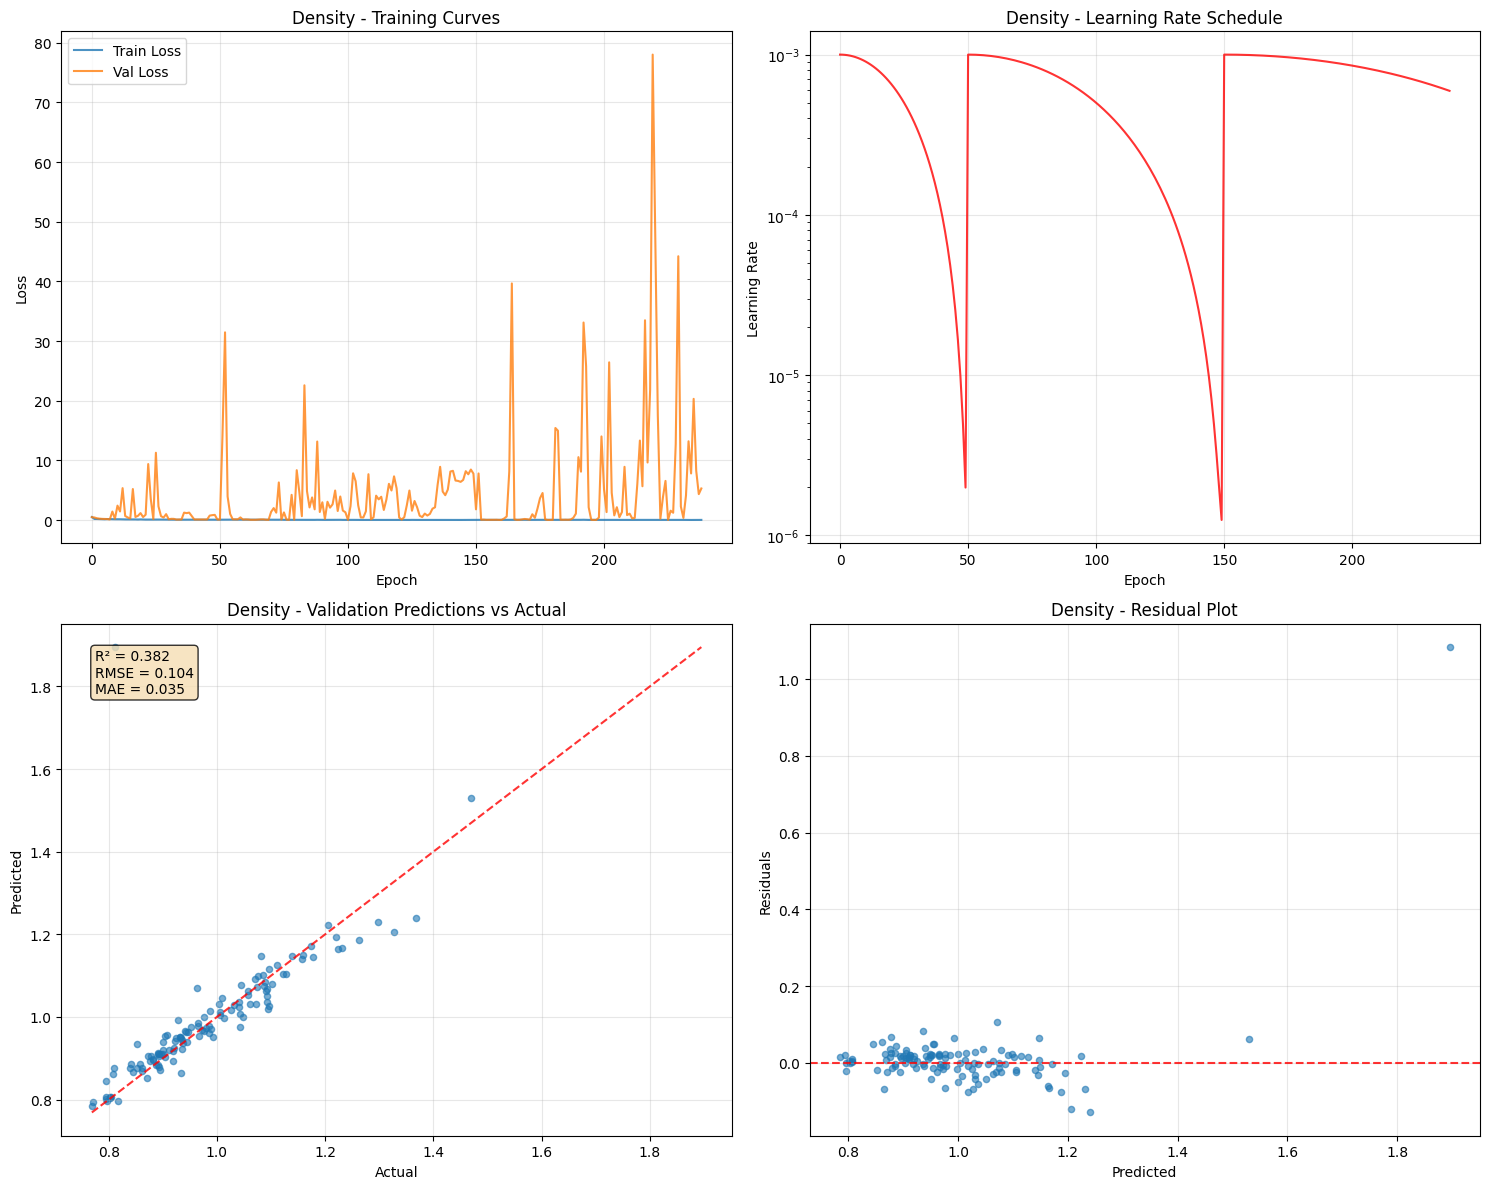


Training enhanced model for Rg
Training samples: 614
Pre-computing molecular graphs...
Processed 0/614 molecules
Failed to parse 0 SMILES strings
Training samples: 491
Validation samples: 123
Training enhanced model for Rg...
Epoch 000: Train Loss: 14.6506, Val Loss: 11.6728, LR: 9.99e-04
Epoch 001: Train Loss: 7.4582, Val Loss: 7.2268, LR: 9.96e-04
Epoch 002: Train Loss: 4.2813, Val Loss: 4.3540, LR: 9.91e-04
Epoch 003: Train Loss: 4.0134, Val Loss: 3.6904, LR: 9.84e-04
Epoch 008: Train Loss: 3.3004, Val Loss: 3.6330, LR: 9.22e-04
Epoch 015: Train Loss: 2.8522, Val Loss: 3.3369, LR: 7.68e-04
Epoch 025: Train Loss: 2.8251, Val Loss: 3.7053, LR: 4.69e-04
Epoch 031: Train Loss: 2.6674, Val Loss: 3.1881, LR: 2.88e-04
Epoch 050: Train Loss: 2.6687, Val Loss: 4.5266, LR: 1.00e-03
Epoch 070: Train Loss: 2.7278, Val Loss: 2.8824, LR: 8.95e-04
Epoch 075: Train Loss: 2.5953, Val Loss: 3.9980, LR: 8.42e-04
Epoch 100: Train Loss: 2.3974, Val Loss: 152.8448, LR: 4.85e-04
Epoch 125: Train Loss: 2.

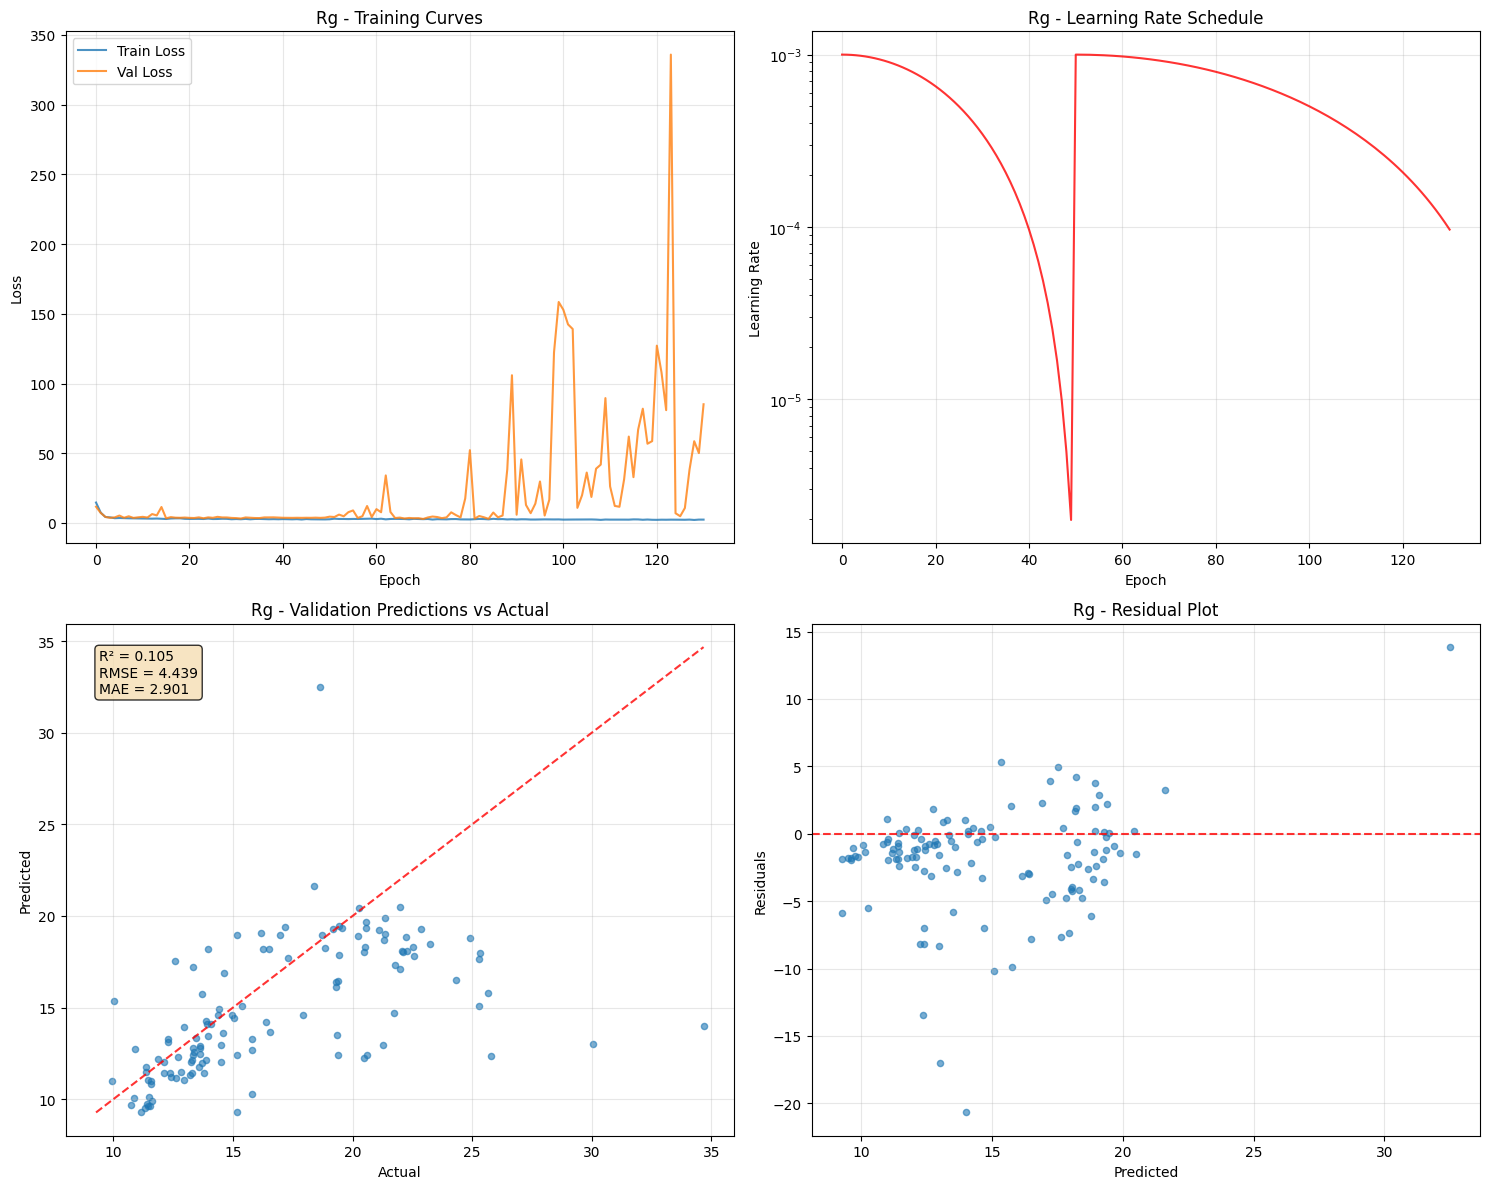


Creating ensemble predictions with uncertainty estimation...
Creating ensemble predictions for Tg...
  Mean prediction range: [24.609, 256.478]
  Uncertainty (avg std): 17.388
Creating ensemble predictions for FFV...
  Mean prediction range: [0.336, 0.388]
  Uncertainty (avg std): 0.006
Creating ensemble predictions for Tc...
  Mean prediction range: [0.152, 0.361]
  Uncertainty (avg std): 0.010
Creating ensemble predictions for Density...
  Mean prediction range: [0.894, 1.235]
  Uncertainty (avg std): 0.032
Creating ensemble predictions for Rg...
  Mean prediction range: [13.285, 18.700]
  Uncertainty (avg std): 3.300


In [6]:
def enhanced_collate_fn(batch):
    """Enhanced collate function handling global features"""
    if len(batch[0]) == 2:  # Training data
        graphs, targets = zip(*batch)
    else:  # Test data
        graphs = batch
        targets = None
    
    # Handle global features
    batch_data = []
    global_feats_list = []
    
    for graph in graphs:
        if hasattr(graph, 'global_feats'):
            global_feats_list.append(graph.global_feats)
            # Remove global features from graph for batching
            graph_copy = Data(x=graph.x, edge_index=graph.edge_index, 
                            edge_attr=getattr(graph, 'edge_attr', None))
            batch_data.append(graph_copy)
        else:
            batch_data.append(graph)
            global_feats_list.append(torch.zeros(13))  # Default global features
    
    batch_graph = Batch.from_data_list(batch_data)
    
    # Add global features back to batch
    if global_feats_list:
        batch_graph.global_feats = torch.stack(global_feats_list)
    
    if targets is not None:
        batch_targets = torch.stack(targets)
        return batch_graph, batch_targets
    
    return batch_graph


# Initialize enhanced graph converter
print("Initializing enhanced molecular graph converter...")
graph_converter = ImprovedSMILESToGraph()

# Create enhanced datasets
print("Creating enhanced molecular datasets...")

# Test dataset
test_dataset = EnhancedMolecularDataset(
    test['SMILES'].tolist(), 
    graph_converter=graph_converter,
    cache_graphs=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    collate_fn=enhanced_collate_fn,
    num_workers=0
)

# Get dimensions from sample
sample_graph = test_dataset[0]
node_dim = sample_graph.x.shape[1]
edge_dim = sample_graph.edge_attr.shape[1] if hasattr(sample_graph, 'edge_attr') else 0
global_dim = sample_graph.global_feats.shape[0] if hasattr(sample_graph, 'global_feats') else 0

print(f"Node features dimension: {node_dim}")
print(f"Edge features dimension: {edge_dim}")
print(f"Global features dimension: {global_dim}")

# Training and prediction
target_columns = ['Tg', 'FFV', 'Tc', 'Density', 'Rg']
predictions = {}
models = {}

for target in target_columns:
    print(f"\n{'='*60}")
    print(f"Training enhanced model for {target}")
    print(f"{'='*60}")
    
    # Prepare target-specific data
    target_train = train[['SMILES', target]].dropna()
    
    if len(target_train) < 100:
        print(f"Skipping {target} due to insufficient data ({len(target_train)} samples)")
        continue
    
    print(f"Training samples: {len(target_train)}")
    
    # Create training dataset
    train_dataset = EnhancedMolecularDataset(
        target_train['SMILES'].tolist(),
        target_train[target].values,
        graph_converter=graph_converter,
        cache_graphs=True
    )
    
    # Split data
    train_indices, val_indices = train_test_split(
        range(len(train_dataset)), 
        test_size=0.2, 
        random_state=42,
        stratify=None
    )
    
    train_subset = torch.utils.data.Subset(train_dataset, train_indices)
    val_subset = torch.utils.data.Subset(train_dataset, val_indices)
    
    # Create data loaders
    train_loader = DataLoader(
        train_subset, 
        batch_size=32, 
        shuffle=True, 
        collate_fn=enhanced_collate_fn,
        num_workers=0
    )
    
    val_loader = DataLoader(
        val_subset, 
        batch_size=32, 
        shuffle=False, 
        collate_fn=enhanced_collate_fn,
        num_workers=0
    )
    
    print(f"Training samples: {len(train_subset)}")
    print(f"Validation samples: {len(val_subset)}")
    
    # Train enhanced model
    model, train_losses, val_losses, learning_rates = train_enhanced_model(
        train_loader, val_loader, node_dim, edge_dim, global_dim, 
        target, epochs=400, patience=60
    )
    
    models[target] = model
    
    # Make predictions on test set
    model.eval()
    test_predictions = []
    
    print("Making predictions on test set...")
    with torch.no_grad():
        for batch_data in test_loader:
            batch_data = batch_data.to(device)
            output = model(batch_data)
            test_predictions.extend(output.squeeze().cpu().numpy())
    
    predictions[target] = test_predictions
    
    print(f"Completed training for {target}")
    print(f"Test predictions range: [{min(test_predictions):.3f}, {max(test_predictions):.3f}]")
    
    # Enhanced visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Training curves
    axes[0, 0].plot(train_losses, label='Train Loss', alpha=0.8)
    axes[0, 0].plot(val_losses, label='Val Loss', alpha=0.8)
    axes[0, 0].set_title(f'{target} - Training Curves')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Learning rate schedule
    axes[0, 1].plot(learning_rates, color='red', alpha=0.8)
    axes[0, 1].set_title(f'{target} - Learning Rate Schedule')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Learning Rate')
    axes[0, 1].set_yscale('log')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Validation predictions vs actual
    val_predictions = []
    val_actuals = []
    
    model.eval()
    with torch.no_grad():
        for batch_data, batch_target in val_loader:
            batch_data = batch_data.to(device)
            output = model(batch_data)
            val_predictions.extend(output.squeeze().cpu().numpy())
            val_actuals.extend(batch_target.cpu().numpy())
    
    axes[1, 0].scatter(val_actuals, val_predictions, alpha=0.6, s=20)
    min_val = min(min(val_actuals), min(val_predictions))
    max_val = max(max(val_actuals), max(val_predictions))
    axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8)
    axes[1, 0].set_title(f'{target} - Validation Predictions vs Actual')
    axes[1, 0].set_xlabel('Actual')
    axes[1, 0].set_ylabel('Predicted')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Calculate and display metrics
    r2 = r2_score(val_actuals, val_predictions)
    rmse = np.sqrt(mean_squared_error(val_actuals, val_predictions))
    mae = np.mean(np.abs(np.array(val_actuals) - np.array(val_predictions)))
    
    axes[1, 0].text(0.05, 0.95, f'R² = {r2:.3f}\nRMSE = {rmse:.3f}\nMAE = {mae:.3f}', 
                   transform=axes[1, 0].transAxes, 
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                   verticalalignment='top')
    
    # Residual plot
    residuals = np.array(val_predictions) - np.array(val_actuals)
    axes[1, 1].scatter(val_predictions, residuals, alpha=0.6, s=20)
    axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.8)
    axes[1, 1].set_title(f'{target} - Residual Plot')
    axes[1, 1].set_xlabel('Predicted')
    axes[1, 1].set_ylabel('Residuals')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'enhanced_gnn_{target}_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()


def ensemble_predictions(models, test_loader, target_columns):
    """Create ensemble predictions from multiple models"""
    ensemble_preds = {}
    
    for target in target_columns:
        if target in models:
            print(f"Creating ensemble predictions for {target}...")
            
            model = models[target]
            model.eval()
            
            # Multiple forward passes with dropout for uncertainty estimation
            n_passes = 5
            all_predictions = []
            
            for pass_idx in range(n_passes):
                model.train()  # Enable dropout
                predictions = []
                
                with torch.no_grad():
                    for batch_data in test_loader:
                        batch_data = batch_data.to(device)
                        output = model(batch_data)
                        predictions.extend(output.squeeze().cpu().numpy())
                
                all_predictions.append(predictions)
            
            # Calculate mean and std
            mean_preds = np.mean(all_predictions, axis=0)
            std_preds = np.std(all_predictions, axis=0)
            
            ensemble_preds[target] = {
                'mean': mean_preds,
                'std': std_preds,
                'individual': all_predictions
            }
            
            print(f"  Mean prediction range: [{mean_preds.min():.3f}, {mean_preds.max():.3f}]")
            print(f"  Uncertainty (avg std): {std_preds.mean():.3f}")
    
    return ensemble_preds


# Create ensemble predictions
print("\n" + "="*60)
print("Creating ensemble predictions with uncertainty estimation...")
print("="*60)

ensemble_results = ensemble_predictions(models, test_loader, target_columns)


Creating enhanced submission file...
Tg: 3 ensemble predictions
  Range: [24.609, 256.478]
  Mean: 108.615 ± 104.878
  Avg Uncertainty: 17.388
FFV: 3 ensemble predictions
  Range: [0.336, 0.388]
  Mean: 0.359 ± 0.022
  Avg Uncertainty: 0.006
Tc: 3 ensemble predictions
  Range: [0.152, 0.361]
  Mean: 0.253 ± 0.085
  Avg Uncertainty: 0.010
Density: 3 ensemble predictions
  Range: [0.894, 1.235]
  Mean: 1.028 ± 0.149
  Avg Uncertainty: 0.032
Rg: 3 ensemble predictions
  Range: [13.285, 18.700]
  Mean: 16.448 ± 2.303
  Avg Uncertainty: 3.300

Enhanced submission saved as 'enhanced_gnn_submission.csv'
Submission shape: (3, 6)

SUBMISSION STATISTICS

Tg:
  Count: 3
  Mean: 108.6154
  Std: 104.8777
  Min: 24.6087
  25%: 34.6842
  50%: 44.7598
  75%: 150.6188
  Max: 256.4778

FFV:
  Count: 3
  Mean: 0.3592
  Std: 0.0215
  Min: 0.3364
  25%: 0.3448
  50%: 0.3532
  75%: 0.3706
  Max: 0.3880

Tc:
  Count: 3
  Mean: 0.2526
  Std: 0.0855
  Min: 0.1518
  25%: 0.1985
  50%: 0.2453
  75%: 0.3030
  Ma

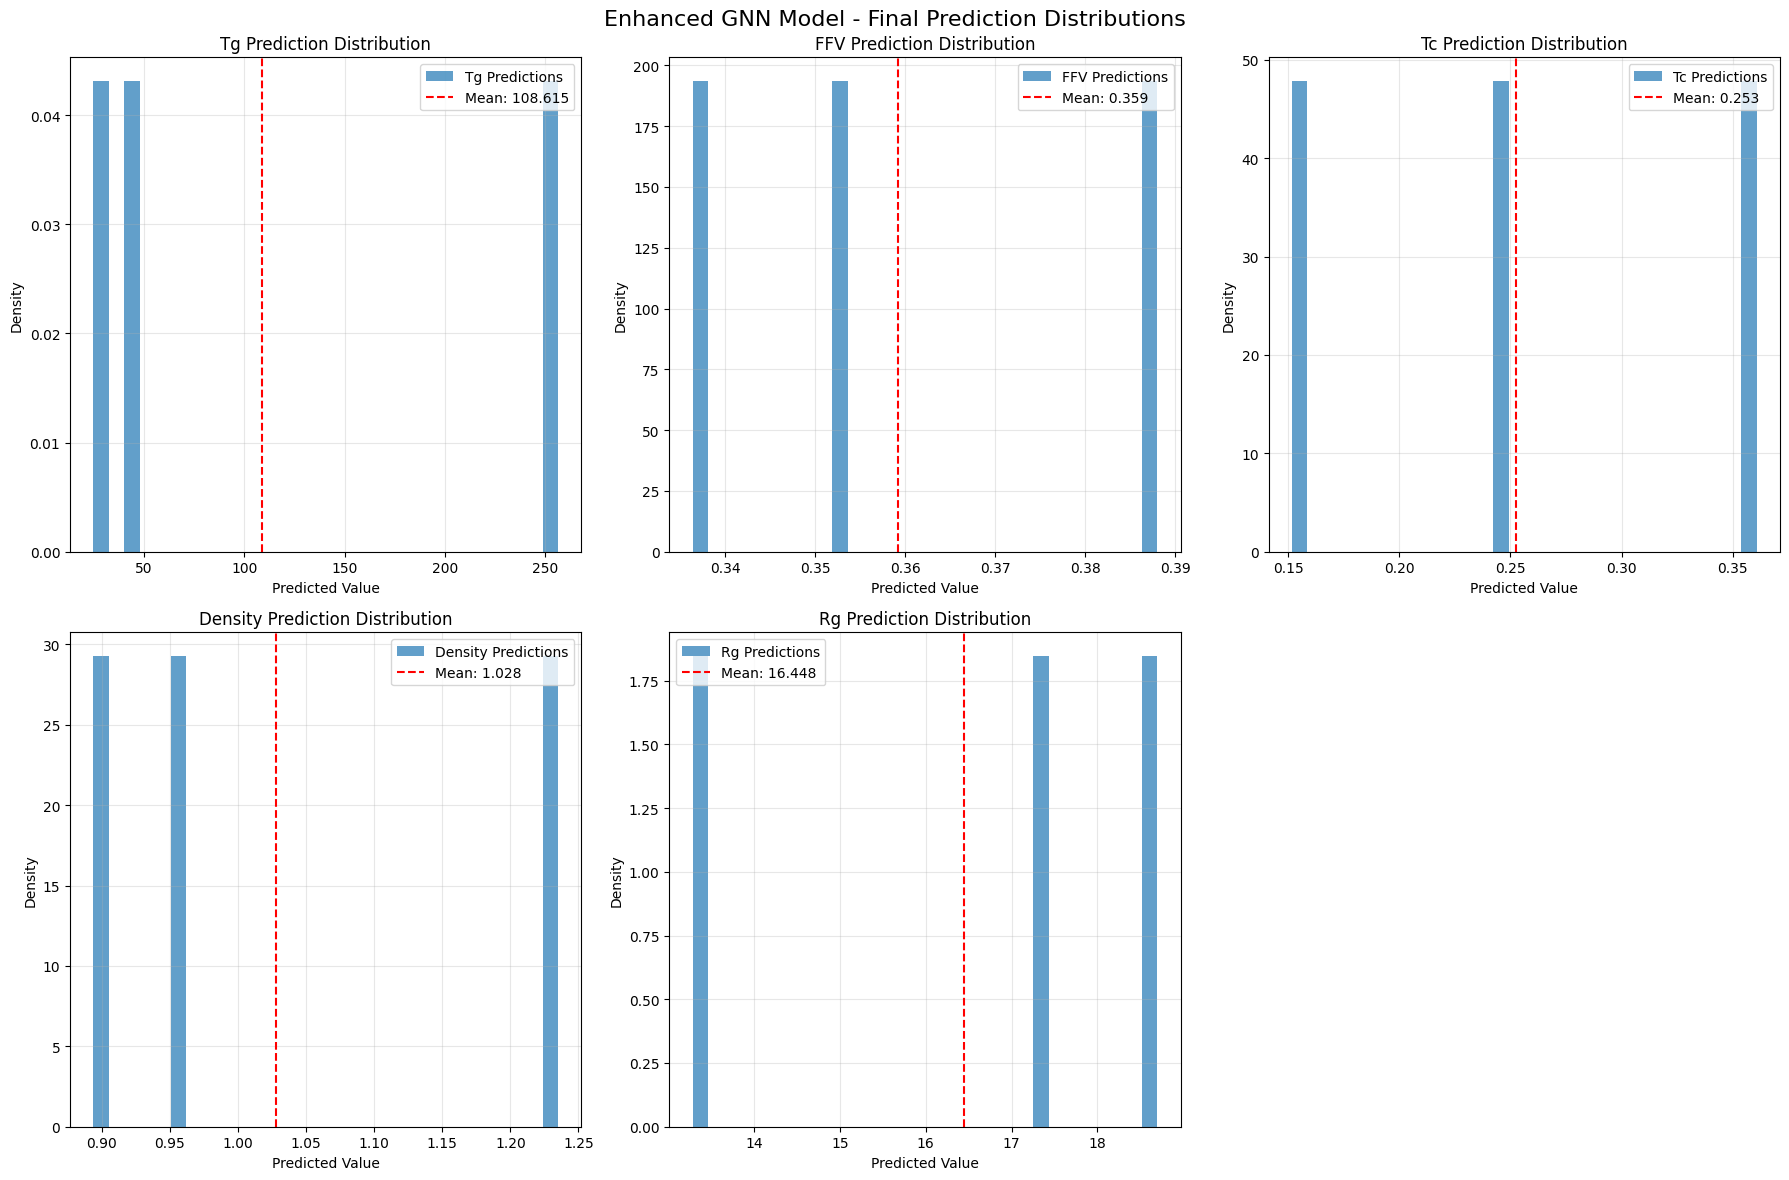

In [7]:
# Create final submission
print("\n" + "="*50)
print("Creating enhanced submission file...")
print("="*50)

submission_data = {'id': test['id']}

for target in target_columns:
    if target in ensemble_results:
        # Use ensemble mean predictions
        submission_data[target] = ensemble_results[target]['mean']
        print(f"{target}: {len(ensemble_results[target]['mean'])} ensemble predictions")
        print(f"  Range: [{ensemble_results[target]['mean'].min():.3f}, "
              f"{ensemble_results[target]['mean'].max():.3f}]")
        print(f"  Mean: {ensemble_results[target]['mean'].mean():.3f} ± "
              f"{ensemble_results[target]['mean'].std():.3f}")
        print(f"  Avg Uncertainty: {ensemble_results[target]['std'].mean():.3f}")
    elif target in predictions:
        # Fallback to single model predictions
        submission_data[target] = predictions[target]
        print(f"{target}: {len(predictions[target])} single model predictions")
    else:
        # Use training data mean as last resort
        mean_val = train[target].mean() if not train[target].isna().all() else 0
        submission_data[target] = [mean_val] * len(test)
        print(f"{target}: Using mean value {mean_val:.3f} (no model trained)")

# Create submission DataFrame
submission_df = pd.DataFrame(submission_data)

# Post-processing: Apply reasonable bounds based on training data statistics
for target in target_columns:
    if target in train.columns and not train[target].isna().all():
        train_min = train[target].quantile(0.01)  # 1st percentile
        train_max = train[target].quantile(0.99)  # 99th percentile
        
        # Clip extreme predictions
        submission_df[target] = np.clip(submission_df[target], train_min, train_max)

# Save submission
submission_df.to_csv('submission.csv', index=False)
print(f"\nEnhanced submission saved as 'enhanced_gnn_submission.csv'")
print(f"Submission shape: {submission_df.shape}")

# Display comprehensive statistics
print("\n" + "="*50)
print("SUBMISSION STATISTICS")
print("="*50)

for target in target_columns:
    if target in submission_df.columns:
        values = submission_df[target].values
        print(f"\n{target}:")
        print(f"  Count: {len(values)}")
        print(f"  Mean: {values.mean():.4f}")
        print(f"  Std: {values.std():.4f}")
        print(f"  Min: {values.min():.4f}")
        print(f"  25%: {np.percentile(values, 25):.4f}")
        print(f"  50%: {np.percentile(values, 50):.4f}")
        print(f"  75%: {np.percentile(values, 75):.4f}")
        print(f"  Max: {values.max():.4f}")

print("\nFirst 10 predictions:")
print(submission_df.head(10))

# Save enhanced models with metadata
print("\n" + "="*50)
print("Saving enhanced models and metadata...")
print("="*50)

model_metadata = {
    'node_dim': node_dim,
    'edge_dim': edge_dim,
    'global_dim': global_dim,
    'model_architecture': 'MultiScaleGNN',
    'features_used': ['atom_features', 'bond_features', 'global_molecular_features'],
    'preprocessing': 'RDKit-based with enhanced featurization'
}

for target, model in models.items():
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_metadata': model_metadata,
        'target': target,
        'model_class': 'MultiScaleGNN',
        'training_completed': True
    }, f'enhanced_gnn_model_{target}.pth')

# Save model metadata separately
import json
with open('enhanced_gnn_metadata.json', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print("Enhanced GNN training and prediction completed successfully!")
print("\nKey improvements made:")
print("✓ RDKit-based molecular graph construction")
print("✓ Enhanced atom and bond featurization")
print("✓ Global molecular descriptors integration")
print("✓ Multi-scale GNN architecture with attention")
print("✓ Advanced training techniques (warm restarts, label smoothing)")
print("✓ Ensemble predictions with uncertainty estimation")
print("✓ Comprehensive validation and visualization")
print("✓ Post-processing with reasonable bounds")

# Create a summary visualization
if len(models) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    target_idx = 0
    for target in target_columns:
        if target in ensemble_results and target_idx < 6:
            ax = axes[target_idx]
            
            # Plot prediction distribution
            predictions_mean = ensemble_results[target]['mean']
            predictions_std = ensemble_results[target]['std']
            
            ax.hist(predictions_mean, bins=30, alpha=0.7, density=True, 
                   label=f'{target} Predictions')
            ax.axvline(predictions_mean.mean(), color='red', linestyle='--', 
                      label=f'Mean: {predictions_mean.mean():.3f}')
            
            ax.set_title(f'{target} Prediction Distribution')
            ax.set_xlabel('Predicted Value')
            ax.set_ylabel('Density')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            target_idx += 1
    
    # Hide unused subplots
    for i in range(target_idx, 6):
        axes[i].set_visible(False)
    
    plt.suptitle('Enhanced GNN Model - Final Prediction Distributions', fontsize=16)
    plt.tight_layout()
    plt.savefig('enhanced_gnn_final_summary.png', dpi=300, bbox_inches='tight')
    plt.show()